# Shoreline change based on land elevation data (AHN 4 and 5)

In [1]:
# read two tiff files (ahn4_merged_cropped.tiff and ahn5_merged_cropped.tiff) from "data_preprocessed\AHN45"
# and subtract the two files and save the result as "ahn45_difference.tiff" in the same folder

import rasterio
import numpy as np

with rasterio.open("data_preprocessed/AHN45/ahn4_merged_cropped.tiff") as src1:
    band1 = src1.read(1)
    transform = src1.transform # to transform the coordinates
    # print the metadata
    print(src1.meta)
    # print coordinate reference system
    print(src1.crs)

with rasterio.open("data_preprocessed/AHN45/ahn5_merged_cropped.tiff") as src2:
    band2 = src2.read(1)

# Subtract the two bands
difference = band2 - band1

# Save the result
with rasterio.open("data_preprocessed/AHN45/ahn45_difference.tiff", "w", **src1.meta) as dst:
    dst.write(difference, 1)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 1200, 'height': 1200, 'count': 1, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(5.0, 0.0, 151800.0,
       0.0, -5.0, 514000.0)}
EPSG:28992


Min: -0.67342323
Max: 13.542089
Mean: 0.02874547
Std: 0.21018371


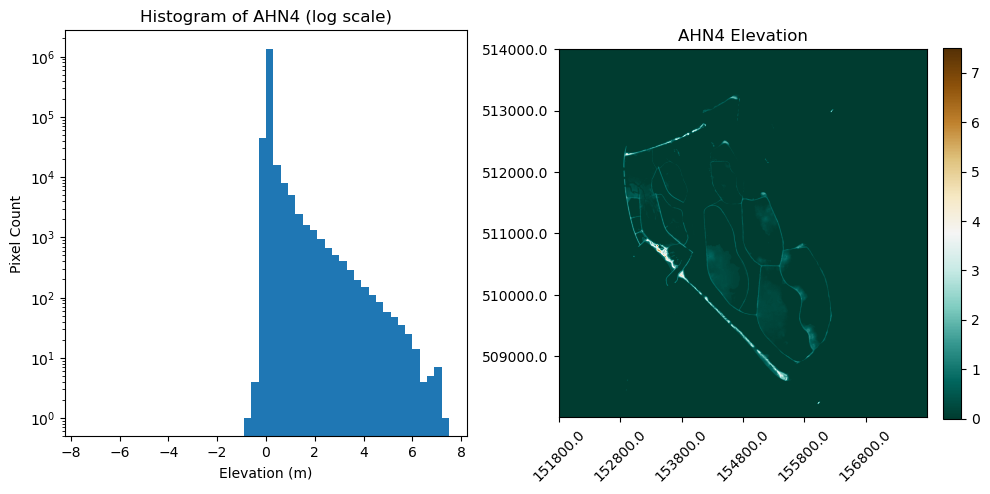

In [2]:
# read ahn4_merged_cropped.tiff and print the min, max, mean, std
# also plot a histogram of the values
# also plot the elevation as an image

import matplotlib.pyplot as plt
with rasterio.open("data_preprocessed/AHN45/ahn4_merged_cropped.tiff") as src:
    ahn4 = src.read(1)
    print("Min:", np.min(ahn4))
    print("Max:", np.max(ahn4))
    print("Mean:", np.mean(ahn4))
    print("Std:", np.std(ahn4))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(ahn4.flatten(), bins=50, range=(-7.5, 7.5), log=True)
    plt.title("Histogram of AHN4 (log scale)")
    plt.xlabel("Elevation (m)")
    plt.ylabel("Pixel Count")

    plt.subplot(1, 2, 2)
    vmax = np.max(np.abs(ahn4))
    img = plt.imshow(ahn4, cmap="bwr", vmin=-vmax, vmax=vmax)
    plt.title("AHN4 Elevation")

    # compute tick positions in pixel coordinates
    xticks = np.arange(0, ahn4.shape[1], 200)
    yticks = np.arange(0, ahn4.shape[0], 200)

    # convert pixel indices to map coordinates using the affine transform
    # transform * (col, row) -> (x, y)
    xtick_labels = [round((transform * (int(c), 0))[0], 2) for c in xticks]
    ytick_labels = [round((transform * (0, int(r)))[1], 2) for r in yticks]

    plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
    plt.yticks(ticks=yticks, labels=ytick_labels)
    vmin, vmax = 0, 7.5
    img = plt.imshow(ahn4, cmap="BrBG_r", vmin=vmin, vmax=vmax)
    plt.colorbar(img, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

Min: -0.50708956
Max: 12.94658
Mean: 0.021476785
Std: 0.24575888


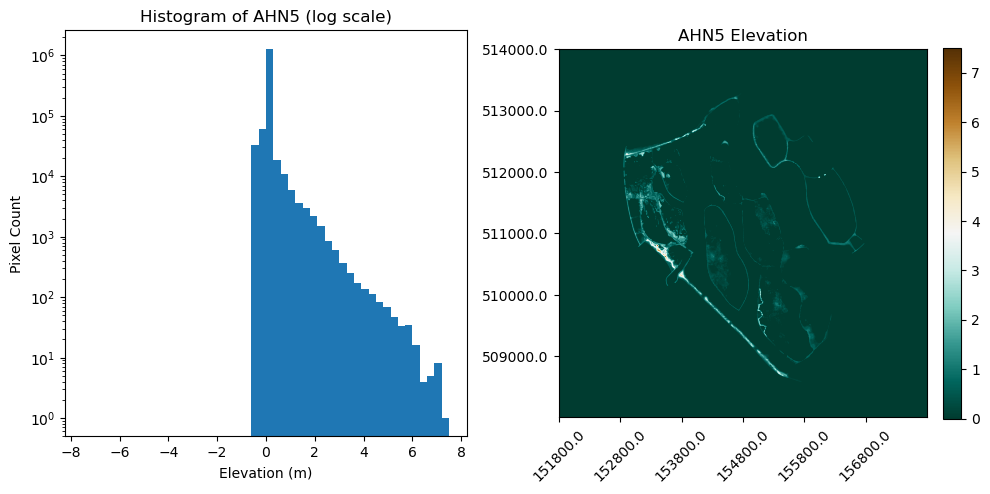

In [3]:
# read ahn5_merged_cropped.tiff and print the min, max, mean, std
# also plot a histogram of the values
# also plot the elevation as an image

import matplotlib.pyplot as plt
with rasterio.open("data_preprocessed/AHN45/ahn5_merged_cropped.tiff") as src:
    ahn5 = src.read(1)
    print("Min:", np.min(ahn5))
    print("Max:", np.max(ahn5))
    print("Mean:", np.mean(ahn5))
    print("Std:", np.std(ahn5))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(ahn5.flatten(), bins=50, range=(-7.5, 7.5), log=True)
    plt.title("Histogram of AHN5 (log scale)")
    plt.xlabel("Elevation (m)")
    plt.ylabel("Pixel Count")

    plt.subplot(1, 2, 2)
    vmax = np.max(np.abs(ahn5))
    img = plt.imshow(ahn5, cmap="bwr", vmin=-vmax, vmax=vmax)
    plt.title("AHN5 Elevation")

    # compute tick positions in pixel coordinates
    xticks = np.arange(0, ahn4.shape[1], 200)
    yticks = np.arange(0, ahn4.shape[0], 200)

    # convert pixel indices to map coordinates using the affine transform
    # transform * (col, row) -> (x, y)
    xtick_labels = [round((transform * (int(c), 0))[0], 2) for c in xticks]
    ytick_labels = [round((transform * (0, int(r)))[1], 2) for r in yticks]

    plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
    plt.yticks(ticks=yticks, labels=ytick_labels)
    vmin, vmax = 0, 7.5
    img = plt.imshow(ahn5, cmap="BrBG_r", vmin=vmin, vmax=vmax)
    plt.colorbar(img, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

C:\Users\Move\AppData\Local\Temp\ipykernel_10556\2039043718.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


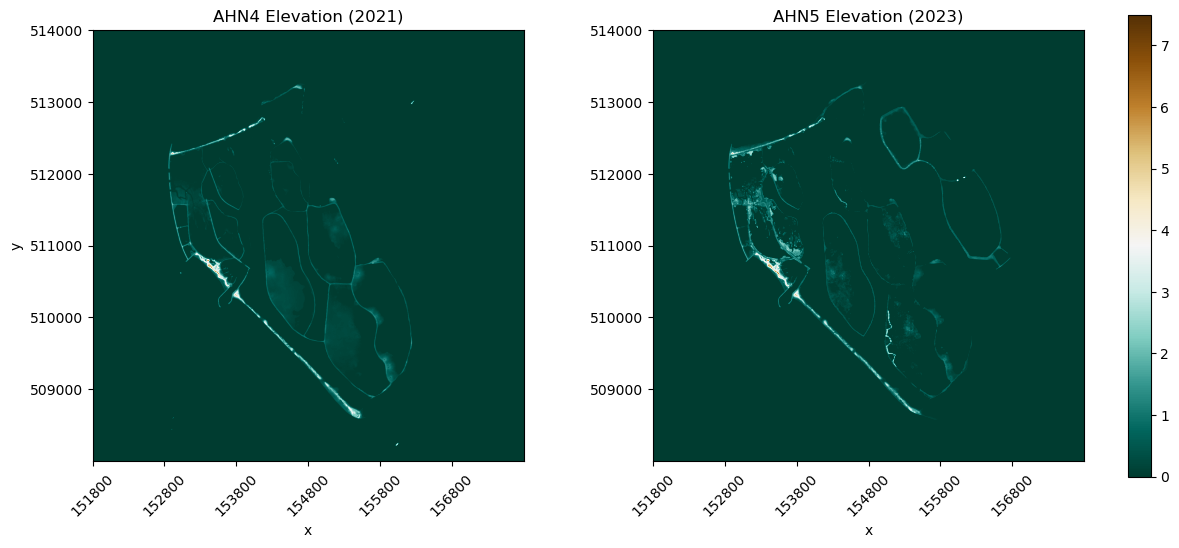

In [4]:
# plot AHN4 on the left and AHN5 on the right (use existing ahn4, ahn5, transform, xtick_labels, ytick_labels)
nrows, ncols = ahn4.shape

# compute map extent from affine transform
xmin = transform.c
xmax = transform.c + ncols * transform.a
ymax = transform.f
ymin = transform.f + nrows * transform.e
extent = (xmin, xmax, ymin, ymax)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.3})

vmin, vmax = 0, 7.5

im0 = axes[0].imshow(ahn4, cmap="BrBG_r", vmin=vmin, vmax=vmax, extent=extent, origin="upper")
axes[0].set_title("AHN4 Elevation (2021)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xticks(xtick_labels)
axes[0].set_yticks(ytick_labels)
axes[0].tick_params(axis="x", rotation=45)

im1 = axes[1].imshow(ahn5, cmap="BrBG_r", vmin=vmin, vmax=vmax, extent=extent, origin="upper")
axes[1].set_title("AHN5 Elevation (2023)")
axes[1].set_xlabel("x")
axes[1].set_xticks(xtick_labels)
axes[1].set_yticks(ytick_labels)
axes[1].tick_params(axis="x", rotation=45)

# Place colorbar to the right of both subplots
cbar = fig.colorbar(im1, ax=axes, location='right', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Min: -9.345329
Max: 5.40259
Mean: -0.0072686817
Std: 0.16710268


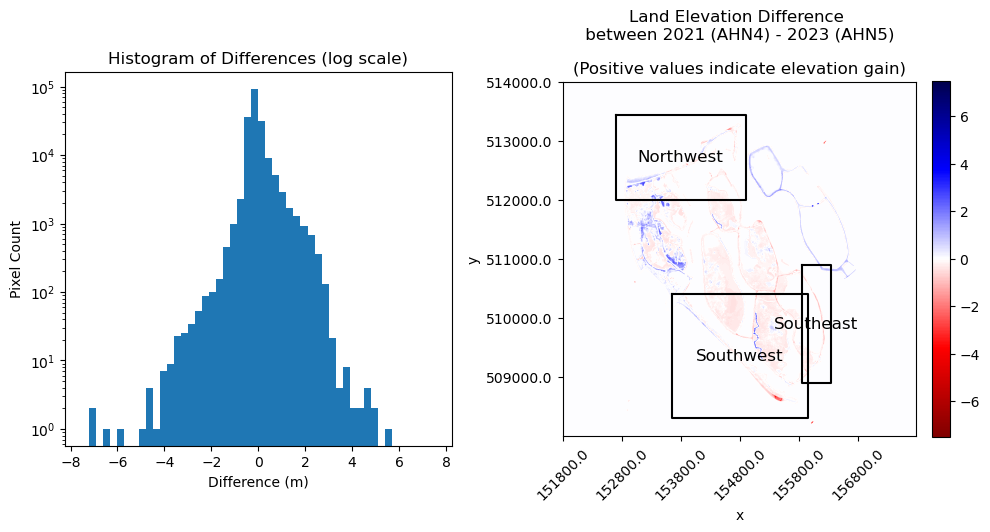

In [5]:
# read ahn45_difference.tiff and print the min, max, mean, std
# also plot a histogram of the values
# also plot the difference as an image

import matplotlib.pyplot as plt
with rasterio.open("data_preprocessed/AHN45/ahn45_difference.tiff") as src:
    difference = src.read(1)
    print("Min:", np.min(difference))
    print("Max:", np.max(difference))
    print("Mean:", np.mean(difference))
    print("Std:", np.std(difference))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    data_nozero = difference.flatten()[difference.flatten() != 0]
    plt.hist(data_nozero, bins=50, range=(-7.5, 7.5), log=True)
    plt.title("Histogram of Differences (log scale)")
    plt.xlabel("Difference (m)")
    plt.ylabel("Pixel Count")

    plt.subplot(1, 2, 2)
    vmax = np.max(np.abs(difference))
    img = plt.imshow(difference, cmap="bwr", vmin=-vmax, vmax=vmax)
    plt.title("Land Elevation Difference \n between 2021 (AHN4) - 2023 (AHN5) \n \n" \
            "(Positive values indicate elevation gain)")

    # compute tick positions in pixel coordinates
    xticks = np.arange(0, difference.shape[1], 200)
    yticks = np.arange(0, difference.shape[0], 200)

    # convert pixel indices to map coordinates using the affine transform
    # transform * (col, row) -> (x, y)
    xtick_labels = [round((transform * (int(c), 0))[0], 2) for c in xticks]
    ytick_labels = [round((transform * (0, int(r)))[1], 2) for r in yticks]

    plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
    plt.yticks(ticks=yticks, labels=ytick_labels)
    # set x y labels
    plt.xlabel("x")
    plt.ylabel("y")

    # Boundaries of study areas in [min_x, min_y, max_x, max_y] format
    study_area = {
        "Northwest": [152700, 512000, 154900, 513450],
        "Southwest": [153650, 508300, 155950, 510400],
        "Southeast": [155850, 508900, 156350, 510900],
    }

    # Keep legacy 'boxes' for downstream cells (list of tuples) and optional names
    boxes = [tuple(coords) for coords in study_area.values()]
    box_names = list(study_area.keys())

    for i, box in enumerate(boxes, start=1):
        minx, miny, maxx, maxy = box

        # convert corners from map coords (x,y) to pixel coords (col,row)
        col_min = int((~transform * (minx, maxy))[0])  # left
        col_max = int((~transform * (maxx, maxy))[0])  # right
        row_min = int((~transform * (minx, maxy))[1])  # top
        row_max = int((~transform * (minx, miny))[1])  # bottom

        plt.plot(
            [col_min, col_max, col_max, col_min, col_min],
            [row_min, row_min, row_max, row_max, row_min],
            color="black"
        )

        # Place label at box center (map center -> pixel center)
        center_col = int((~transform * ((minx + maxx) / 2, (miny + maxy) / 2))[0])
        center_row = int((~transform * ((minx + maxx) / 2, (miny + maxy) / 2))[1])
        name = box_names[i-1] if (i-1) < len(box_names) else f"Box {i}"
        plt.text(center_col, center_row, name, color="black", fontsize=12, ha='center', va='center')

    vmin, vmax = -7.5, 7.5
    img = plt.imshow(difference, cmap="seismic_r", vmin=vmin, vmax=vmax)
    plt.colorbar(img, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

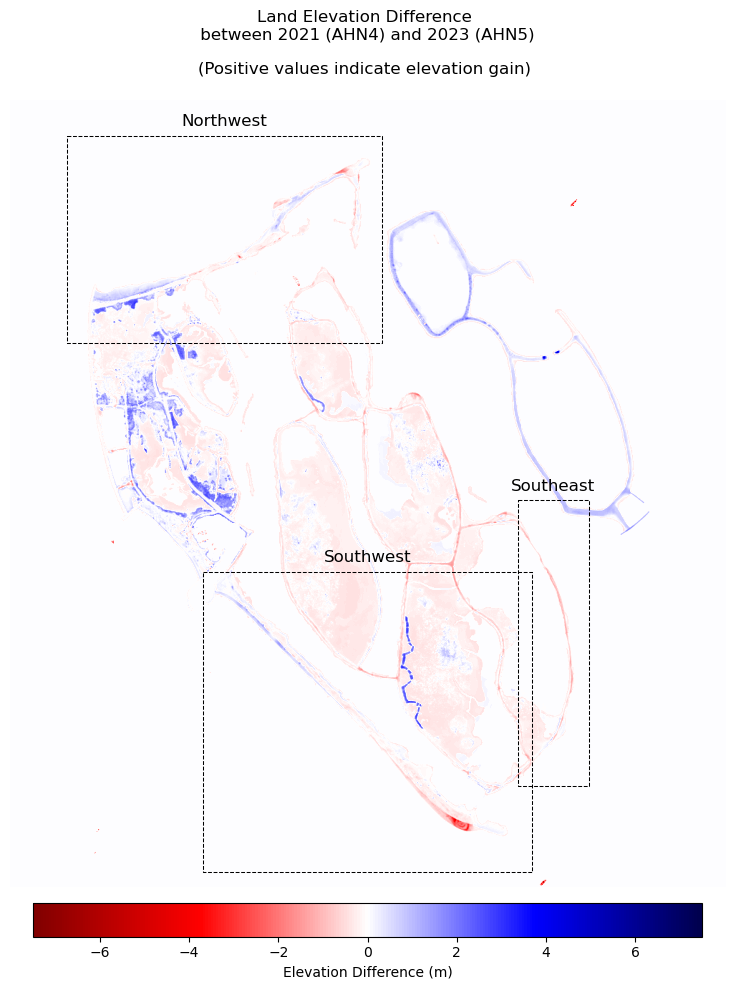

In [6]:
# plot only the image (right plot) of ahn45_difference.tiff

import matplotlib.pyplot as plt

with rasterio.open("data_preprocessed/AHN45/ahn45_difference.tiff") as src:
    difference = src.read(1)
    transform = src.transform

# compute extent in map coordinates
nrows, ncols = difference.shape
xmin = transform.c
xmax = transform.c + ncols * transform.a
ymax = transform.f
ymin = transform.f + nrows * transform.e
extent = (xmin, xmax, ymin, ymax)

vmin, vmax = -7.5, 7.5

plt.figure(figsize=(10, 10))
img = plt.imshow(difference, cmap="seismic_r", vmin=vmin, vmax=vmax, extent=extent, origin="upper")
plt.title("Land Elevation Difference \n between 2021 (AHN4) and 2023 (AHN5) \n \n" \
            "(Positive values indicate elevation gain) \n")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")

# draw boundaries of study areas
study_area = {
    "Northwest": [152700, 512000, 154900, 513450],
    "Southwest": [153650, 508300, 155950, 510400],
    "Southeast": [155850, 508900, 156350, 510900],
}
for i, (name, box) in enumerate(study_area.items(), start=1):
    minx, miny, maxx, maxy = box

    # convert corners from map coords (x,y) to pixel coords (col,row)
    col_min = int((~transform * (minx, maxy))[0])  # left
    col_max = int((~transform * (maxx, maxy))[0])  # right
    row_min = int((~transform * (minx, maxy))[1])  # top
    row_max = int((~transform * (minx, miny))[1])  # bottom

    plt.plot(
        [minx, maxx, maxx, minx, minx],
        [maxy, maxy, miny, miny, maxy],
        color="black",
        linewidth=0.75,
        linestyle="--"
    )

    # Place label at box center
    center_x = (minx + maxx) / 2
    center_y = maxy + 100
    plt.text(center_x, center_y, name, color="black", fontsize=12, ha='center', va='center')

# create map-coordinate ticks every ~200 pixels
xticks_pix = np.arange(0, ncols, 200)
yticks_pix = np.arange(0, nrows, 200)
map_xticks = [round((transform * (int(c), 0))[0], 2) for c in xticks_pix]
map_yticks = [round((transform * (0, int(r)))[1], 2) for r in yticks_pix]

plt.xticks(ticks=map_xticks, labels=map_xticks, rotation=45)
plt.yticks(ticks=map_yticks, labels=map_yticks)
plt.xlim(xmin+500, xmax-500)
plt.ylim(ymin+200, ymax-300)

plt.colorbar(img, fraction=0.04, pad=0.02, orientation='horizontal',
             label='Elevation Difference (m)')

plt.axis("off")
plt.tight_layout()
plt.show()


Selected Box 4: (155800, 509500, 156800, 510500)
Box shape (meters): (1000, 1000)
Box shape (pixels, floats): (200.0, 200.0)
Pixel slice rows: (700, 900) cols: (800, 1000)


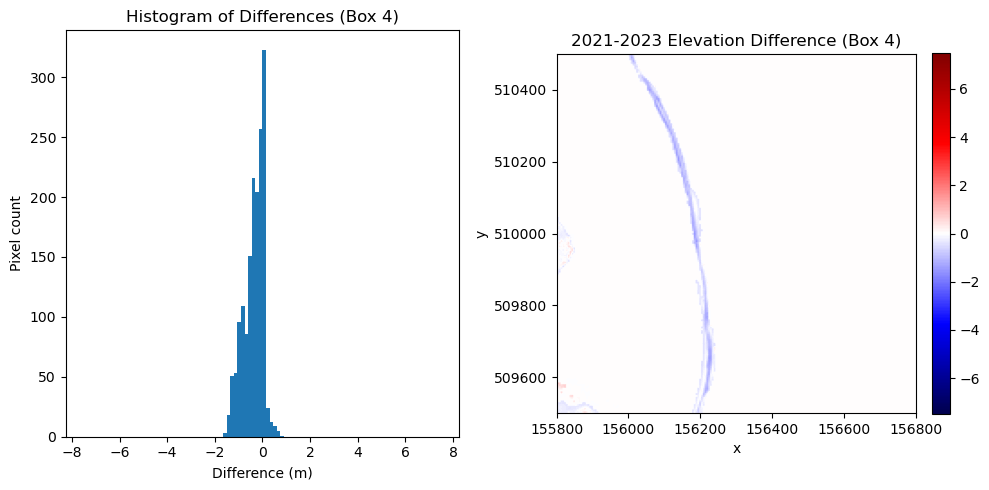

In [7]:
# Define boxes (in map coordinates)
boxes = [
    (152800, 511500, 153800, 512500),
    (153300, 510000, 154300, 511000),
    (154300, 508500, 155300, 509500),
    (155800, 509500, 156800, 510500),
]

# change this index to choose a different box (0 to 3)
box_index = 3

if not (0 <= box_index < len(boxes)):
    raise IndexError(f"box_index out of range, must be 0..{len(boxes)-1}")

# select box and show info
box = boxes[box_index]
minx, miny, maxx, maxy = box
print(f"Selected Box {box_index+1}: {box}")

# box size in meters
print("Box shape (meters):", (maxx - minx, maxy - miny))

# convert map coords -> pixel coords using inverse affine
col_min_f, row_min_f = (~transform) * (minx, maxy)
col_max_f, row_max_f = (~transform) * (maxx, miny)

# pixel size (approx)
pixel_width = col_max_f - col_min_f
pixel_height = row_max_f - row_min_f
print("Box shape (pixels, floats):", (pixel_width, pixel_height))

# round and clamp to array bounds
nrows, ncols = difference.shape
col_min = max(0, min(ncols, int(round(col_min_f))))
col_max = max(0, min(ncols, int(round(col_max_f))))
row_min = max(0, min(nrows, int(round(row_min_f))))
row_max = max(0, min(nrows, int(round(row_max_f))))

# ensure proper ordering for slicing
row0, row1 = sorted((row_min, row_max))
col0, col1 = sorted((col_min, col_max))

print("Pixel slice rows:", (row0, row1), "cols:", (col0, col1))

crop = difference[row0:row1, col0:col1]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
data_nozero = crop.flatten()[crop.flatten() != 0]
plt.hist(data_nozero, bins=100, range=(vmin, vmax))
plt.title(f"Histogram of Differences (Box {box_index+1})")
plt.xlabel("Difference (m)")
plt.ylabel("Pixel count")

plt.subplot(1, 2, 2)
# show crop with map coordinate extent so axes show real coordinates
img = plt.imshow(crop, cmap="seismic", vmin=vmin, vmax=vmax,
                 extent=(minx, maxx, miny, maxy), origin="upper")
plt.title(f"2021-2023 Elevation Difference (Box {box_index+1})")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(img, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Pixel slice rows: (720, 1140) cols: (370, 830)


C:\Users\Move\AppData\Local\Temp\ipykernel_10556\3960215530.py:82: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  CS4.collections[0].set_label("AHN4 coastline (2021)")
C:\Users\Move\AppData\Local\Temp\ipykernel_10556\3960215530.py:89: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  CS5.collections[0].set_label("AHN5 coastline (2023)")


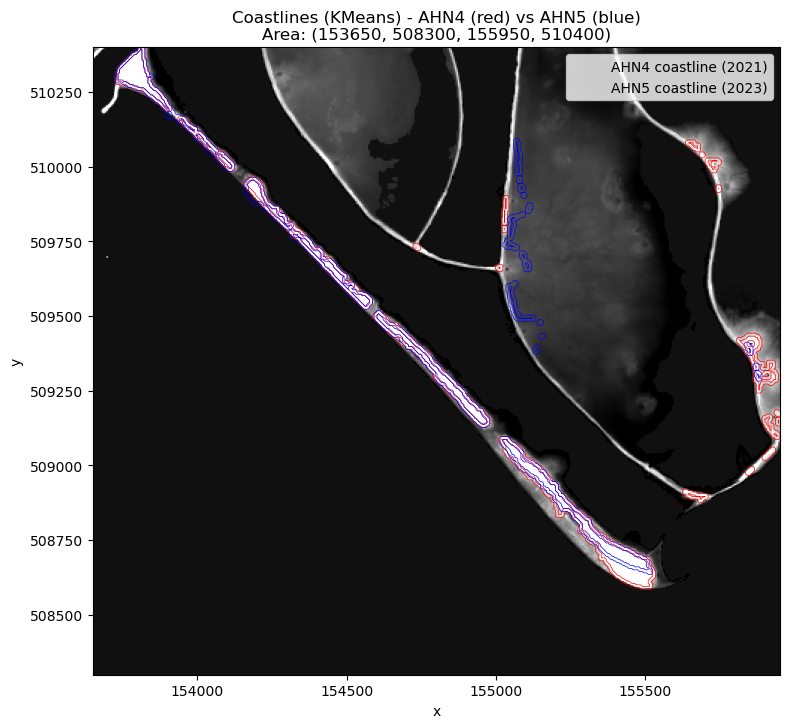

In [18]:
from sklearn.cluster import KMeans

# Extract and plot coastlines (KMeans-based) for AHN4 (2021) and AHN5 (2023)
# in the area: minx, miny, maxx, maxy = 154300, 508500, 155300, 509500
# Uses existing variables: transform, ahn4, ahn5 (from previous cells)

import scipy.ndimage as ndi

# bbox in map coordinates (user-specified)
minx, miny, maxx, maxy = 153650, 508300, 155950, 510400

def map_bbox_to_pixel_slice(transform, minx, miny, maxx, maxy, arr_shape):
    # Convert map coords -> pixel coords using inverse affine (~transform)
    col_min_f, row_min_f = (~transform) * (minx, maxy)  # top-left
    col_max_f, row_max_f = (~transform) * (maxx, miny)  # bottom-right

    nrows, ncols = arr_shape
    col0 = max(0, min(ncols, int(round(col_min_f))))
    col1 = max(0, min(ncols, int(round(col_max_f))))
    row0 = max(0, min(nrows, int(round(row_min_f))))
    row1 = max(0, min(nrows, int(round(row_max_f))))

    # Ensure ordering
    row0, row1 = sorted((row0, row1))
    col0, col1 = sorted((col0, col1))
    return row0, row1, col0, col1

def extract_coastline_by_kmeans(elev_crop, n_clusters=2, opening_size=3):
    # elev_crop: 2D array for the region
    # Returns boolean mask of coastline pixels
    mask_valid = np.isfinite(elev_crop)
    vals = elev_crop[mask_valid].reshape(-1, 1)
    if vals.size < 2:
        return None  # not enough data
    # Fit KMeans on elevation values
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto')
    kmeans.fit(vals)
    centers = kmeans.cluster_centers_.flatten()
    labels_full = np.full(elev_crop.shape, -1, dtype=int)
    labels_full[mask_valid] = kmeans.labels_
    # land cluster = cluster with higher center value
    land_label = int(np.argmax(centers))
    land_mask = (labels_full == land_label)
    # clean small speckles
    structure = np.ones((opening_size, opening_size), dtype=bool)
    land_clean = ndi.binary_opening(land_mask, structure=structure)
    # coastline as the boundary pixels (land minus its eroded version)
    eroded = ndi.binary_erosion(land_clean, structure=structure)
    coastline = np.logical_xor(land_clean, eroded)
    return coastline, land_clean

# compute pixel slice for the bbox using one of the arrays (they have the same shape/transform)
row0, row1, col0, col1 = map_bbox_to_pixel_slice(transform, minx, miny, maxx, maxy, ahn4.shape)
print("Pixel slice rows:", (row0, row1), "cols:", (col0, col1))

# crop the elevations
crop_ahn4 = ahn4[row0:row1, col0:col1].astype(float)
crop_ahn5 = ahn5[row0:row1, col0:col1].astype(float)

# run KMeans and get coastlines
coast_4, land_4 = extract_coastline_by_kmeans(crop_ahn4)
coast_5, land_5 = extract_coastline_by_kmeans(crop_ahn5)

# Prepare coordinate grids for plotting contours in map coordinates
nx = crop_ahn4.shape[1]
ny = crop_ahn4.shape[0]
x = np.linspace(minx, maxx, nx)
y = np.linspace(maxy, miny, ny)  # descending so row=0 corresponds to y=maxy (origin='upper' convention)
X, Y = np.meshgrid(x, y)

# Plot background (AHN4 elevation) and overlay coastlines for both epochs
plt.figure(figsize=(8, 8))
vmin, vmax = np.nanpercentile(crop_ahn4, 2), np.nanpercentile(crop_ahn4, 98)
plt.imshow(crop_ahn4, cmap="gray", vmin=vmin, vmax=vmax, extent=(minx, maxx, miny, maxy), origin="upper")
plt.title("Coastlines (KMeans) - AHN4 (red) vs AHN5 (blue)\nArea: %s" % str((minx, miny, maxx, maxy)))
plt.xlabel("x")
plt.ylabel("y")

# overlay AHN4 coastline
if coast_4 is not None and np.any(coast_4):
    CS4 = plt.contour(X, Y, coast_4.astype(int), levels=[0], colors=["red"], linewidths=0.5)
    CS4.collections[0].set_label("AHN4 coastline (2021)")
else:
    print("No coastline found for AHN4 in this bbox")

# overlay AHN5 coastline
if coast_5 is not None and np.any(coast_5):
    CS5 = plt.contour(X, Y, coast_5.astype(int), levels=[0], colors=["blue"], linewidths=0.5)
    CS5.collections[0].set_label("AHN5 coastline (2023)")
else:
    print("No coastline found for AHN5 in this bbox")

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Optionally, save the coastlines as GeoTIFF masks (uncomment to enable)
# with rasterio.open("data_preprocessed/AHN45/coastline_ahn4_box3.tiff", "w", **src1.meta) as dst:
#     dst.write(coast_4.astype(np.uint8), 1)
# with rasterio.open("data_preprocessed/AHN45/coastline_ahn5_box3.tiff", "w", **src1.meta) as dst:
#     dst.write(coast_5.astype(np.uint8), 1)